In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('C:/Users/MSIS/Downloads/AML/MLLabprojects/data/Iris.csv')

x = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, random_state = 42, stratify = y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)
x_test

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
107,7.3,2.9,6.3,1.8
13,4.3,3.0,1.1,0.1
133,6.3,2.8,5.1,1.5
6,4.6,3.4,1.4,0.3
127,6.1,3.0,4.9,1.8
140,6.7,3.1,5.6,2.4
3,4.6,3.1,1.5,0.2
19,5.1,3.8,1.5,0.3
70,5.9,3.2,4.8,1.8
141,6.9,3.1,5.1,2.3


In [2]:
print(x.columns)

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='str')


In [3]:
#fitting decision tree classification to the training set
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'gini', random_state = 42)
classifier.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [4]:
#predicting the test set results
y_pred = classifier.predict(x_test)
y_pred

array([2, 1, 0, 1, 2, 2, 1, 1, 2, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 2, 1, 0,
       1, 2, 2, 1, 1, 1, 1, 0, 0, 2, 1, 0, 2, 0, 0, 0, 0, 1, 1, 0, 0, 2,
       1])

In [5]:
y_test

107    2
13     1
133    2
6      1
127    2
140    2
3      1
19     1
70     0
141    2
64     0
88     0
108    2
116    2
78     0
148    2
7      1
60     0
73     0
68     0
47     1
57     0
25     1
104    2
138    2
1      1
34     1
43     1
16     1
85     0
134    2
132    2
35     1
99     0
111    2
90     0
92     0
52     0
93     0
27     1
5      1
72     0
106    2
147    2
8      1
Name: Species, dtype: int64

In [6]:
#making the confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[13,  0,  2],
       [ 0, 15,  0],
       [ 3,  0, 12]])

In [7]:
accuracy = (cm[0][0] + cm[1][1] + cm[2][2]) / cm.sum()
accuracy

np.float64(0.8888888888888888)

In [8]:
from sklearn import metrics
#model accuracy, how often is the classifier correct?
prediction = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:",prediction*100, '%')

Accuracy: 88.88888888888889 %


In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       1.00      1.00      1.00        15
           2       0.86      0.80      0.83        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



In [10]:
#predict for a new sample with all 4 features:
#[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
import numpy as np
new_individual = np.array([[5.1, 3.5, 1.4, 0.2]])

#scale the new features
new_individual_scaled = scaler.transform(new_individual)

#predict using the trained classifier
prediction = classifier.predict(new_individual_scaled)
print("Predicted Class:", prediction[0])

Predicted Class: 1


c:\Users\MSIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\MSIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


[Text(0.5714285714285714, 0.9166666666666666, 'x[2] <= 2.45\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]'),
 Text(0.42857142857142855, 0.75, 'gini = 0.0\nsamples = 35\nvalue = [0, 35, 0]'),
 Text(0.5, 0.8333333333333333, 'True  '),
 Text(0.7142857142857143, 0.75, 'x[3] <= 1.75\ngini = 0.5\nsamples = 70\nvalue = [35, 0, 35]'),
 Text(0.6428571428571428, 0.8333333333333333, '  False'),
 Text(0.5714285714285714, 0.5833333333333334, 'x[0] <= 7.1\ngini = 0.102\nsamples = 37\nvalue = [35, 0, 2]'),
 Text(0.42857142857142855, 0.4166666666666667, 'x[1] <= 2.25\ngini = 0.054\nsamples = 36\nvalue = [35, 0, 1]'),
 Text(0.2857142857142857, 0.25, 'x[3] <= 1.25\ngini = 0.5\nsamples = 2\nvalue = [1, 0, 1]'),
 Text(0.14285714285714285, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.42857142857142855, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.5714285714285714, 0.25, 'gini = 0.0\nsamples = 34\nvalue = [34, 0, 0]'),
 Text(0.71428571428571

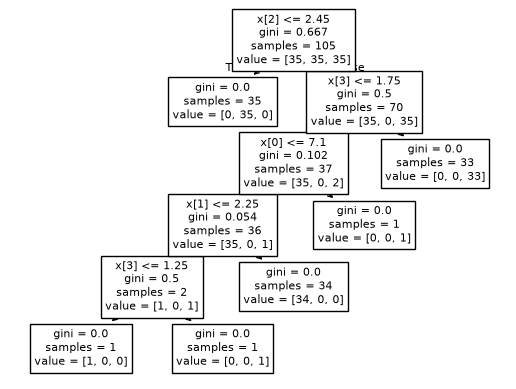

In [11]:
from sklearn import tree
tree.plot_tree(classifier)

K-FOLD CROSS VALIDATION, K=3

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

classifier = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

scores = cross_val_score(
    classifier,
    x,
    y,
    cv=skfold,
    scoring='accuracy'
)

print("K = 3")
print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

K = 3
Fold Accuracies: [1.   0.92 0.94]
Mean Accuracy: 0.9533333333333333


K-FOLD CROSS VALIDATION, K=5

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifier = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

scores = cross_val_score(
    classifier,
    x,
    y,
    cv=skfold,
    scoring='accuracy'
)

print("K = 5")
print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

K = 5
Fold Accuracies: [1.         0.96666667 0.93333333 0.96666667 0.9       ]
Mean Accuracy: 0.9533333333333335


K-FOLD CROSS VALIDATION, K=10

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

classifier = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

scores = cross_val_score(
    classifier,
    x,
    y,
    cv=skfold,
    scoring='accuracy'
)

print("K = 10")
print("Fold Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

K = 10
Fold Accuracies: [1.         0.93333333 1.         0.93333333 0.86666667 0.86666667
 1.         0.93333333 0.93333333 0.86666667]
Mean Accuracy: 0.9333333333333333
